### imports

In [3]:
import numpy as np
import tensorflow as tf 
import tensorflow.experimental.numpy as tnp 

In [4]:
tnp.experimental_enable_numpy_behavior()

In [5]:
import matplotlib.pyplot as plt 

### 우도함수

**(motivation example)**

$X_i \overset{iid}{\sim} Ber(p)$에서 얻은 샘플이 아래와 같다고 하자. 

In [6]:
x=[0,1,0,1] 
x

[0, 1, 0, 1]

$p$는 얼마라고 볼 수 있는가? --> 0.5 

왜??

`-` suppose: $p=0.1$ 이라고 하자. 

그렇다면 $(x_1,x_2,x_3,x_4)=(0,1,0,1)$와 같은 샘플이 얻어질 확률이 아래와 같다. 

In [7]:
0.9 * 0.1 * 0.9 * 0.1 

0.008100000000000001

`-` suppose: $p=0.2$ 이라고 하자. 

그렇다면 $(x_1,x_2,x_3,x_4)=(0,1,0,1)$와 같은 샘플이 얻어질 확률이 아래와 같다. 

In [8]:
0.8 * 0.2 * 0.8 * 0.2 

0.025600000000000008

`-` 질문: $p=0.1$인것 같냐? 아니면 $p=0.2$인것 같냐? -> $p=0.2$ 
- 왜?? $p=0.2$일 ~~확률~~이 더 높다. 

`-` (여기서 잠깐 중요한것) 확률이라는 말을 함부로 쓸 수 없다. 
- 0.0256은 "$p=0.2$일경우 샘플 (0,1,0,1)이 얻어질 확률"이지 "$p=0.2$일 확률"은 아니다.

In [22]:
_plist = np.linspace(0.499,0.501,1000)
_prob = [(1-p)*p*(1-p)*p for p in _plist]
# p=0.499일 확률은 0.06249950000099999 이고 
# ... 
# p=0.501일 확률은 0.062499500001?? 
# 확률인데 저거 더하면 다 더하면 1 넘어? 

`-` 확률이라는 말은 쓸 수 없지만 확률의 느낌은 있다. -> 가능도라는 말을 쓰자.
- 0.0256 = p가 0.2 일 경우 샘플 (0,1,0,1)이 얻어질 확률 = p가 0.2일 가능도! 

`-` 다시 질문1로 돌아가자!
- 질문1: $p=0.1$인것 같냐? 아니면 $p=0.2$인것 같냐? -> 답: $p=0.2$ -> 왜? $p=0.2$인 가능도가 더 크니까. 
- 질문2: $p=0.2$인것 같냐? 아니면 $p=0.3$인것 같냐? -> 답: $p=0.3$ -> 왜? $p=0.3$인 가능도가 더 크니까. 
- ... 

`-` 궁극의 질문: $p$가 뭐일 것 같아? 
- $p$를 입력으로 넣으면 가능도가 계산되는 함수를 만들자. 
- 그 함수를 최대화하는 $p$를 찾자. 
- 그 $p$가 궁극의 질문에 대한 대답이 된다. 

`-` 용어정리 
- 가능도함수 = 우도함수 = likelihood function = $L(p)$ 
- likelihood function을 최대화하는 $p$ = $p$의 maximum likelihood estimator = $p$의 MLE = $\hat{p}$

`-` 이 예제의 경우 가능도함수를 정의하자.
- $L(p)$ = $p$일 가능도 = $p$가 모수일때 샘플 (0,1,0,1)이 얻어질 확률 = $\prod_{i=1}^{4}$ $p$가 모수일때 샘플 $x_i$가 얻어질 확률 = $\prod_{i=1}^{4} f(x_i;p)$


- $f(x_i;p)=p_i^{x_i} (1-p_i)^{1-x_i}$

`-` 일반화: $X_1,\dots,X_n \overset{iid}{\sim} Ber(p)$ 일때 $p$의 likelihood function은 $\prod_{i=1}^{n} p_i^{x_i}(1-p_i)^{1-x_i}$

- 더 일반화: $X_1,\dots,X_n$이 pdf가 $f(x)$인 분포에서 뽑힌 서로 독립인 샘플이라고 하자. 이때 likelihood function은 $\prod_{i=1}^{n}f(x_i)$이다. 

`-` 이 예제의 경우 최대우도추정량을 구하면 
- $L(p)= p^2(1-p)^2$ 
- $L(p)$를 최대화하는 $p$는 0.5이다. 따라서 $\hat{p}^{mle}=0.5$

### 중간고사 1번 

`(1)` $N(\mu,\sigma)$에서 얻은 샘플이 아래와 같다고 할때 $\mu,\sigma$의 MLE를 구하여라. 
```
<tf.Tensor: shape=(10000,), dtype=float64, numpy=
array([ 4.12539849,  5.46696729,  5.27243374, ...,  2.89712332,
        5.01072291, -1.13050477])>
```

`(2)` $Ber(p)$에서 얻은 샘플이 아래와 같다고 할때 $p$의 MLE를 구하라. 
```
<tf.Tensor: shape=(10000,), dtype=int64, numpy=array([0, 0, 1, ..., 1, 1, 1])>
```

`(3)` $y_i = \beta_0 + \beta_1 x_i +\epsilon_i$, $\epsilon_i \overset{iid}{\sim} N(0,1)$ 일때 $(\beta_0,\beta_1)$의 MLE를 구하라. (어? 이거 회귀모형임!)

(풀이) 

$$L(\beta_0,\beta_1)=\prod_{i=1}^{n}f(y_i), \quad f(y_i)=\frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}(y_i-\mu_i)^2}, \quad \mu_i=\beta_0+\beta_1 x_i$$

를 최대화하는 $\beta_0,\beta_1$을 구하면 된다. 

그런데 이것은 아래를 최소화하는 $\beta_0,\beta_1$을 구하는 것과 같다. 

$$ - \log L(\beta_0,\beta_1) = \sum_{i=1}^{n}(y_i-\beta_0-\beta_1 x_i)^2$$

어? 이거 SSE이다! 결국 오차항이 정규분포를 따르는 회귀모형의 MLE는 MSE를 최소화하는 $\beta_0,\beta_1$을 구하면 되는거였군! (SSE를 최소화하는 $\beta_0,\beta_1$은 MSE=SSE/N 도 최소화)

**중간고사 1-(3)의 다른 풀이**

step1: 시뮬레이팅 

In [24]:
x= tf.constant(np.arange(1,10001)/10000)
y= tnp.random.randn(10000) + (0.5 + 2*x) 

step2: estimate 

주어진 함수를 최대화하는 $\beta_0,\beta_1$은 MSE를 최소화하는 $\beta_0,\beta_1$와 동일하므로 

In [25]:
beta0= tf.Variable(1.0)
beta1= tf.Variable(1.0) 
for i in range(2000):
    with tf.GradientTape() as tape: 
        # minus_log_likelihood =  tf.reduce_mean((y-beta0-beta1*x)**2) 
        loss = tf.reduce_mean((y-beta0-beta1*x)**2) 
    slope1, slope2 = tape.gradient(loss,[beta0,beta1]) 
    beta0.assign_sub(slope1* 0.1)
    beta1.assign_sub(slope2* 0.1) 

In [26]:
beta0,beta1

(<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=0.53167033>,
 <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=1.9530661>)

**note:** `loss = -log_likelihood` 
- 손실함수를 선택: -로그우도함수 <-- 이렇게하면된다?

`(4)` 제출하지 못한 중간고사 문제 

아래의 모형에 따라서 $\{Y_i\}_{i=1}^{10000}$를 생성하는 코드를 작성하라. 
- $Y_i \overset{iid}{\sim} Ber(\pi_i)$
- $\pi_i = \frac{exp(w_0+w_1x_i)}{1+\exp(w_0+w_1x_i)}=\frac{exp(-1+5x_i)}{1+\exp(-1+5x_i)}$ where x = tnp.linspace(-1,1,2000)

함수 $L(w_0,w_1)$을 최대화하는 $(w_0,w_1)$를 `tf.GradeintTape()`를 활용하여 추정하라. (경사하강법 혹은 경사상승법을 사용하고 $(w_0,w_1)$의 초기값은 모두 0.1로 설정할 것)

$$L(w_0,w_1)=\prod_{i=1}^{n}f(y_i), \quad f(x_i)={\pi_i}^{y_i}(1-\pi_i)^{1-y_i},\quad \pi_i=\text{sigmoid}(w_0+w_1y_i)$$

(풀이) 

아래의 우도함수 

$$L(w_0,w_1)=\prod_{i=1}^{n}f(y_i), \quad f(x_i)={\pi_i}^{y_i}(1-\pi_i)^{1-y_i},\quad \pi_i=\text{sigmoid}(w_0+w_1x_i)$$

를 최대화하는 $w_0,w_1$은 아래를 최소화하는 $w_0,w_1$와 같다. 

$$-log L(w_0,w_1) = - \sum_{i=1}^{n}\big(y_i \log(\pi_i) + (1-y_i)\log(1-\pi_i)\big)$$

이거 바이너리 크로스 엔트로피??

$$\hat{\pi}_i=\text{sigmoid}(\hat{w}_0+\hat{w}_1x_i)= \hat{y}_i$$

결국 로지스틱 모형에서 $(w_0,w_1)$의 MLE를 구하기 위해서는 BCEloss를 최소화하는 $(w_0,w_1)$을 구하면 된다!

(코딩)

In [180]:
### 데이터생성 
x = tnp.linspace(-1,1,2000)
pi = tnp.exp(-1+5*x) / (1+tnp.exp(-1+5*x))
y = np.random.binomial(1,pi); y = tf.constant(y)

In [184]:
### -로그우도함수 최소화
w0hat = tf.Variable(1.0)
w1hat = tf.Variable(1.0)

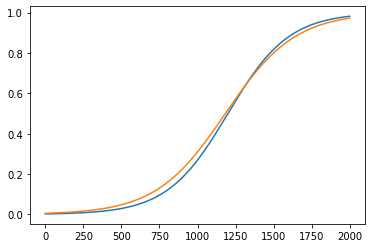

In [185]:
for i in range(1000): 
    with tf.GradientTape() as tape: 
        pihat = tnp.exp(w0hat + x*w1hat) / (1+tnp.exp(w0hat + x*w1hat)) 
        pdf = pihat**y * (1-pihat)**(1-y) 
        logL = tf.reduce_mean(tnp.log(pdf))
    slope1,slope2 = tape.gradient(logL,[w0hat,w1hat]) 
    w0hat.assign_add(slope1*0.1)
    w1hat.assign_add(slope2*0.1)
plt.plot(pi)
plt.plot(pihat)

### 손실함수의 설계

`-` 오차항의 분포가 알려진 경우 "손실함수 = -로그우도함수"로 설계하면 된다. 
- 오차항이 정규분포인 회귀모형: 손실함수를 MSEloss로 선택! 왜? -log_likelihood = MSEloss 니까. 
- 오차항이 베르누이인 로지스틱회귀모형: 손실함수를 BCEloss로 선택! => 왜? -log_likelihood = BCEloss 니까. 

`-` -로그우도함수가 손실함수를 선택하는 유일한 기준은 아니다!
- 오차항이 대칭인 회귀모형: 손실함수를 MSEloss로 선택! 왜? MSEloss를 최소화하는 $\beta$는 BLUE가 된다! (가우스-마코프정리)